## Graphs, `networkx` library

#### Graphs

A **graph** or a **network** -- any model/system with:

+ elements = nodes = vertices
+ relations = edges

Can you think of some examples of graphs and networks around us? And in linguistics?

#### Why do we need graphs?

+ visualization
+ network analysis



The `networkx` library ([documentation](https://networkx.github.io/documentation/latest/index.html)) allows us to work with graphs. Not the only library for working with graphs in python ([some other choices](https://wiki.python.org/moin/PythonGraphLibraries)).

#### Networks

In [ ]:
!pip install networkx

In [1]:
import networkx as nx

#### Creating a graph

In [4]:
G = nx.Graph() # an empty graph

In [5]:
G.add_node(1) # adding a node

In [6]:
G.add_nodes_from([2 ,3, 4, 5, 6, 7]) # adding some nodes

In [7]:
G.remove_node(2) # deleting a node

In [8]:
# labeling nodes, using their ids (1,2,3 etc.)
G.add_node(1, label="node_1")

In [9]:
G.add_nodes_from([(4, {"color": "red"}), (5, {"color": "blue"}),])

Adding relations:

In [10]:
G.add_edge(1,3) # an edge between 1 and 3
G.add_edges_from([(1, 4), (1, 5), (3, 5), (4, 5), (1, 6), (1, 7)]) # multiple edges
G.remove_edge(1, 5) # removing an edge

Printing the result:

In [11]:
print('nodes', G.nodes())
print('edges', G.edges())

nodes [1, 3, 4, 5, 6, 7]
edges [(1, 3), (1, 4), (1, 6), (1, 7), (3, 5), (4, 5)]


In [12]:
G.number_of_nodes()

6

In [13]:
G.number_of_edges()

6

In [14]:
# the number of neighbors for a node
G.degree(5)

2

In [15]:
# neighbors for each node
for node in G.nodes():
    print (node, G.degree(node))

1 4
3 2
4 2
5 2
6 1
7 1


In [16]:
list(G.adj[5])

[3, 4]

In [17]:
list(G.neighbors(5))

[3, 4]

Weighted graphs, where the relations are weighted:

In [18]:
# adding the weight

G.add_edge(1, 3, weight=4)

We can add the direction of the relation:

In [19]:
dg = nx.DiGraph()
dg.add_weighted_edges_from([(1,4,0.5), (3,1,0.75)]) # from, to, weight

Can you summarize the types of the graphs?

To set the type of the graph:

  - ```Graph``` - a simple graph, two nodes are connected by one edge

  - ```DiGraph``` - a directed graph

  - ```MultiGraph``` - a graph with multiple edges per node

  - ```MultiDiGraph``` - a directed graph with multiple edges per node


#### Saving the graph

You can use various formats:

+ csv -- for nodes, for relations
+ gml (Graph Modelling Language) -- text format for graphs
+ graphml — XML format for graphs
+ gexf (Graph Exchange XML Format) — XML format with metadata for graphs (the most extensive).

To save your graph:


In [ ]:
nx.write_gexf(G, 'graph_file.gexf')

To read a graph:

In [ ]:
G1 = nx.read_gexf('graph_file.gexf')

#### Visualization

We will use `matplotlib` ([other options](https://networkx.github.io/documentation/networkx-2.2/reference/drawing.html)).


In [20]:
DG = nx.DiGraph()

DG.add_edges_from([('blue', 'navy'), ('green', 'blue'), ('navy', 'black'), ('black', 'blue')])

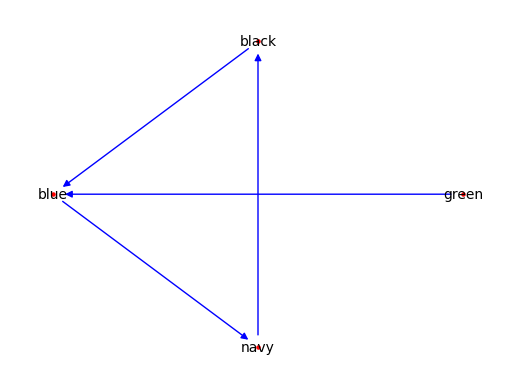

In [22]:
import matplotlib.pyplot as plt

#other layout options: random_layout, shell_layout, spring_layout
pos=nx.shell_layout(DG)

nx.draw_networkx_nodes(DG, pos, node_color='red', node_size=5)
nx.draw_networkx_edges(DG, pos, edge_color='blue')
nx.draw_networkx_labels(DG, pos, font_size=10)
plt.axis('off')
plt.show()

In [24]:
# to extract a subgraph
sub = ['navy', 'blue', 'black']
sub_DG = DG.subgraph(sub)
print(sub_DG.number_of_nodes())

3


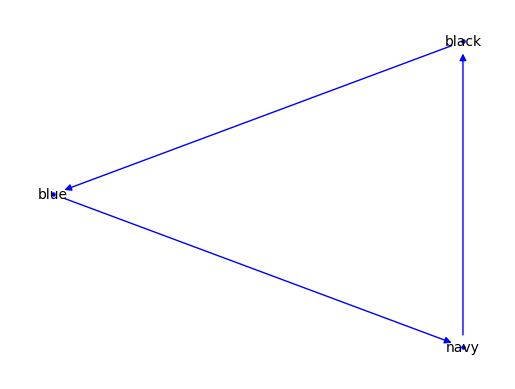

In [25]:
pos=nx.shell_layout(sub_DG)

nx.draw_networkx_nodes(sub_DG, pos, node_color='blue', node_size=5)
nx.draw_networkx_edges(sub_DG, pos, edge_color='blue')
nx.draw_networkx_labels(sub_DG, pos, font_size=10)
plt.axis('off')
plt.show()

Let's create a graph for DECEIT, based on the data from the CLICS database (https://clics.clld.org/)

In [26]:
DECEIT = nx.Graph()

DECEIT.add_weighted_edges_from([('SLEEP', 'LIE (MISLEAD)', 3), ('LIE (MISLEAD)', 'PERJURY', 13), ('LIE (MISLEAD)', 'DECEIT', 43), ('PERJURY', 'DECEIT', 8), ('DECEIT', 'BETRAY', 6), ('BETRAY', 'SELL', 25), ('SELL', 'GIVE', 27), ('GIVE', 'BETRAY', 9), ('DECEIT', 'WRONG', 5), ('WRONG', 'BAD', 27), ('WRONG', 'CROOKED', 12), ('WRONG', 'GUILTY', 33), ('WRONG', 'FAULT', 26), ('WRONG', 'MISS (A TARGET)', 5), ('WRONG', 'MISTAKE', 37), ('MISTAKE', 'CROOKED', 3), ('MISTAKE', 'FAULT', 71), ('MISTAKE', 'MISS (A TARGET)', 13), ('MISS (A TARGET)', 'FAULT', 4), ('FAULT', 'GUILTY', 9)])

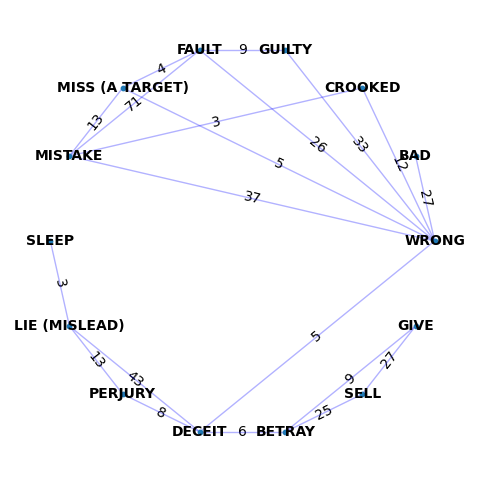

In [31]:
import matplotlib.pyplot as plt

pos=nx.shell_layout(DECEIT)

plt.figure(figsize=(6, 6))

nx.draw_networkx_nodes(DECEIT, pos, node_size=10)
labels = nx.get_edge_attributes(DECEIT,'weight')
nx.draw_networkx_edge_labels(DECEIT, pos, edge_labels=labels)
nx.draw_networkx_edges(DECEIT, pos, alpha=0.3, edge_color='blue')
nx.draw_networkx_labels(DECEIT, pos, font_size=10, font_weight='bold')
plt.axis('off')
plt.show()

In [32]:
# Diameter of the graph, found by first measuring the shortest path between every pair of vertices, and then taking the maximum of those shortest distances
print(nx.diameter(DECEIT))

4


In [34]:
print('average shortest path: ', nx.average_shortest_path_length(DECEIT))

average shortest path:  2.5054945054945055


In [35]:
print(DECEIT.number_of_nodes())
print(DECEIT.number_of_edges())

14
20


In [36]:
print(nx.density(DECEIT)) #the edge count divided by the possible number of edges in the graph

0.21978021978021978


In [37]:
print(nx.degree_pearson_correlation_coefficient(G))#Assortativity in a graph is the tendency of nodes to connect with other nodes that share similar attributes or properties

-0.7333333333333334


+ **Density** - the number of edges divided by the possible number of edges

+ **Degree** – the number of relations

+ **Weighted degree** – the number of relations of a node divided by the total number of relations in the graph

+ **Centrality**:
    + **degree centrality**: the more relations, the more important the node
    + **closeness centrality**: the more central (closer to other nodes), the more important the node
    + **betweenness centrality**: the number of closest paths that go through the node
    + **eigencentrality**: the more friends your neighbors have, the more important you are

[Relevant documentation](https://networkx.github.io/documentation/networkx-2.2/reference/algorithms/centrality.html).

In [38]:
from collections import Counter

In [39]:
components = nx.components.connected_components(DECEIT)

component_lengths = Counter([len(i) for i in components])

component_lengths.most_common()

[(14, 1)]

In [40]:
components = nx.components.connected_components(DECEIT)
nodes = sorted([(i, len(i)) for i in components], key=lambda x: x[1], reverse=True)[0][0]
len(nodes)

14

In [41]:
B = DECEIT.subgraph(nodes)

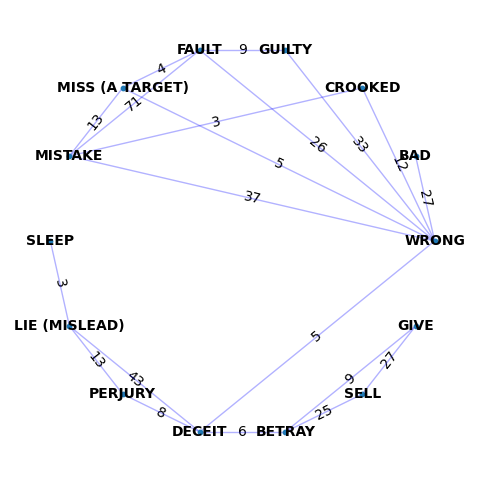

In [42]:
pos=nx.shell_layout(B)

plt.figure(figsize=(6, 6))

nx.draw_networkx_nodes(B, pos, node_size=10)
labels = nx.get_edge_attributes(B,'weight')
nx.draw_networkx_edge_labels(B, pos, edge_labels=labels)
nx.draw_networkx_edges(B, pos, alpha=0.3, edge_color='blue')
nx.draw_networkx_labels(B, pos, font_size=10, font_weight='bold')
plt.axis('off')
plt.show()

In [43]:
deg = nx.degree_centrality(DECEIT)
for nodeid in sorted(deg, key=deg.get, reverse=True):
    print(nodeid)

WRONG
DECEIT
FAULT
MISTAKE
LIE (MISLEAD)
BETRAY
MISS (A TARGET)
PERJURY
SELL
GIVE
CROOKED
GUILTY
SLEEP
BAD


In [44]:
b = nx.betweenness_centrality(DECEIT)
for nodeid in sorted(b, key=b.get, reverse=True):
    print(nodeid)

DECEIT
WRONG
BETRAY
LIE (MISLEAD)
FAULT
MISTAKE
SLEEP
PERJURY
SELL
GIVE
BAD
CROOKED
GUILTY
MISS (A TARGET)


In [45]:
b = nx.closeness_centrality(DECEIT)
for nodeid in sorted(b, key=b.get, reverse=True):
    print(nodeid)

DECEIT
WRONG
BETRAY
LIE (MISLEAD)
FAULT
MISTAKE
PERJURY
MISS (A TARGET)
CROOKED
GUILTY
BAD
SELL
GIVE
SLEEP


In [46]:
b = nx.eigenvector_centrality(DECEIT)
for nodeid in sorted(b, key=b.get, reverse=True):
    print(nodeid)

WRONG
FAULT
MISTAKE
MISS (A TARGET)
CROOKED
GUILTY
DECEIT
BAD
LIE (MISLEAD)
PERJURY
BETRAY
SELL
GIVE
SLEEP


**Clustering coefficient** – the probability that the closest neighbors of a node will be connected to each other

In [47]:
print(nx.average_clustering(DECEIT))
print(nx.transitivity(DECEIT))

0.6003401360544218
0.4528301886792453


**Modularity** shows to what extent the density within communities of a given community structure is higher than the density between communities.

**Community** – sets of nodes densely connected internally.

![](https://focus.ua/files/medvedeva/2016/04/01-11/gofthr.jpg)

In [48]:
from networkx.algorithms import community

[Here](https://networkx.github.io/documentation/latest/reference/algorithms/community.html) you can find algorythms for generating communities:

In [56]:
communities_generator = community.girvan_newman(DECEIT) # takes out one by one edges with highest betweenness centrality
top_level_communities = next(communities_generator)
next_level_communities = next(communities_generator)
third_level_communities = next(communities_generator)
forth_level_communities = next(communities_generator)
fifth_level_communities = next(communities_generator)
sixth_level_communities = next(communities_generator)
print("top level communities:", sorted(map(sorted, top_level_communities)))
print("next level communities:", sorted(map(sorted, next_level_communities)))
print("third level communities:", sorted(map(sorted, third_level_communities)))
print("forth level communities:", sorted(map(sorted, forth_level_communities)))
print("fifth level communities:", sorted(map(sorted, fifth_level_communities)))
print("sixth level communities:", sorted(map(sorted, sixth_level_communities)))

top level communities: [['BAD', 'CROOKED', 'FAULT', 'GUILTY', 'MISS (A TARGET)', 'MISTAKE', 'WRONG'], ['BETRAY', 'DECEIT', 'GIVE', 'LIE (MISLEAD)', 'PERJURY', 'SELL', 'SLEEP']]
next level communities: [['BAD', 'CROOKED', 'FAULT', 'GUILTY', 'MISS (A TARGET)', 'MISTAKE', 'WRONG'], ['BETRAY', 'GIVE', 'SELL'], ['DECEIT', 'LIE (MISLEAD)', 'PERJURY', 'SLEEP']]
third level communities: [['BAD'], ['BETRAY', 'GIVE', 'SELL'], ['CROOKED', 'FAULT', 'GUILTY', 'MISS (A TARGET)', 'MISTAKE', 'WRONG'], ['DECEIT', 'LIE (MISLEAD)', 'PERJURY', 'SLEEP']]
forth level communities: [['BAD'], ['BETRAY', 'GIVE', 'SELL'], ['CROOKED', 'FAULT', 'GUILTY', 'MISS (A TARGET)', 'MISTAKE', 'WRONG'], ['DECEIT', 'LIE (MISLEAD)', 'PERJURY'], ['SLEEP']]
fifth level communities: [['BAD'], ['BETRAY', 'GIVE', 'SELL'], ['CROOKED'], ['DECEIT', 'LIE (MISLEAD)', 'PERJURY'], ['FAULT', 'GUILTY', 'MISS (A TARGET)', 'MISTAKE', 'WRONG'], ['SLEEP']]
sixth level communities: [['BAD'], ['BETRAY', 'GIVE', 'SELL'], ['CROOKED'], ['DECEIT', '

In [50]:
communities_generator_2 = community.greedy_modularity_communities(DECEIT) # relies upon modularity which, in turn, relies upon density
communities_generator_2

[frozenset({'BAD',
            'CROOKED',
            'FAULT',
            'GUILTY',
            'MISS (A TARGET)',
            'MISTAKE',
            'WRONG'}),
 frozenset({'DECEIT', 'LIE (MISLEAD)', 'PERJURY', 'SLEEP'}),
 frozenset({'BETRAY', 'GIVE', 'SELL'})]

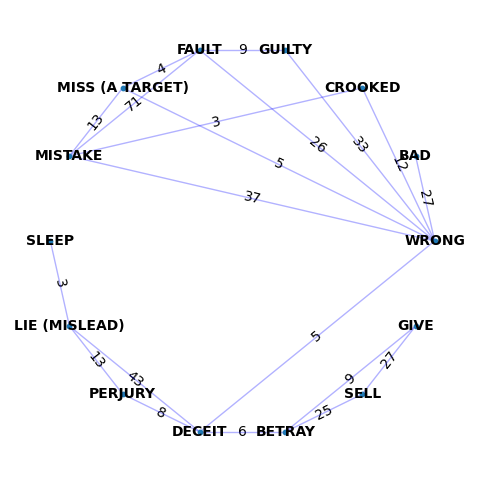

In [51]:
pos=nx.shell_layout(DECEIT)

plt.figure(figsize=(6, 6))

nx.draw_networkx_nodes(DECEIT, pos, node_size=10)
labels = nx.get_edge_attributes(DECEIT,'weight')
nx.draw_networkx_edge_labels(DECEIT, pos, edge_labels=labels)
nx.draw_networkx_edges(DECEIT, pos, alpha=0.3, edge_color='blue')
nx.draw_networkx_labels(DECEIT, pos, font_size=10, font_weight='bold')
plt.axis('off')
plt.show()

#### Gephi

Gephi is a program that allows you to create, visualize a graph. If you want a beautiful graph, you can process the data in python, upload it to gephi, and create and visualize the graph there.

#### Graphs and linguistics

You can find a list of relevant papers [here](https://www.cs.upc.edu/~rferrericancho/linguistic_and_cognitive_networks.html)

Dracor https://dracor.org/, where you can find graphs for novels.